# Fine-tune Qwen2.5-VL-3B-Instruct với Unsloth QLoRA

**Target platform:** Kaggle T4 | Colab | Local RTX 5060 Ti

**Data sources (upload lên Kaggle Dataset tên `a20-finetune-data`):**
- `question_bank.jsonl` — 1,276 MCQs (CS224n, CS231n, CS230)
- `units.jsonl` — 376 learning units
- `qa_history.jsonl` — 58 production Q&A (optional)

**Strategy:** MCQ → 3 ChatML variants (~3,800 samples) + unit summaries (~376 samples)

**Split:** Theo `lecture_id` để tránh data leakage

---
### Kaggle setup (làm 1 lần)
1. Vào `kaggle.com/datasets` → New Dataset → upload 3 files → đặt tên `a20-finetune-data`
2. Trong notebook: **+ Add Data** → tìm `a20-finetune-data` → Add
3. Settings → Accelerator → **GPU T4 × 1**
4. Run All

## 0. Environment detection & Install

In [16]:
import os
import sys
from pathlib import Path

if os.path.exists("/kaggle/working"):
    ENV = "kaggle"
elif os.path.exists("/content"):
    ENV = "colab"
else:
    ENV = "local"

print(f"Environment: {ENV}")

Environment: kaggle


In [17]:
if ENV == "local":
    os.system('pip install "unsloth[cu128] @ git+https://github.com/unslothai/unsloth.git" -q')
else:
    os.system('pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git" -q')

os.system('pip install transformers datasets accelerate trl bitsandbytes matplotlib -q')

0

In [18]:
import torch

print(f"GPU:  {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"CUDA: {torch.version.cuda}")

# Ampere+ (sm>=80) mới support bf16 hardware — T4 là sm_75, phải dùng fp16
major, _ = torch.cuda.get_device_capability(0)
USE_BF16  = major >= 8
USE_FP16  = not USE_BF16
print(f"Compute capability: sm_{major}x → precision: {'bf16' if USE_BF16 else 'fp16'}")

GPU:  Tesla T4
VRAM: 15.6 GB
CUDA: 12.8
Compute capability: sm_7x → precision: fp16


## 1. Paths & Load Data

In [19]:
import json

if ENV == "kaggle":
    DATA_ROOT = Path("/kaggle/input/datasets/nguynnc/a20-finetune-data")
    OUT_ROOT  = Path("/kaggle/working")
elif ENV == "colab":
    DATA_ROOT = Path("/content/drive/MyDrive/a20-data")
    OUT_ROOT  = Path("/content/outputs")
else:
    DATA_ROOT = Path("../data/final_artifacts/cs224n_cs231n_cs230_v1/canonical")
    OUT_ROOT  = Path(".")

QUESTION_BANK = DATA_ROOT / "question_bank.jsonl"
UNITS_FILE    = DATA_ROOT / "units.jsonl"
QA_HISTORY    = DATA_ROOT / "qa_history.jsonl"
OUTPUT_DIR    = OUT_ROOT / "data/sft"
CKPT_DIR      = OUT_ROOT / "checkpoints/tutor-vl3b-v1"
MODEL_DIR     = OUT_ROOT / "models/tutor-vl3b-v1-merged"

# Kiểm tra input files tồn tại trước khi chạy
assert QUESTION_BANK.exists(), f"Missing: {QUESTION_BANK}"
assert UNITS_FILE.exists(),    f"Missing: {UNITS_FILE}"
print("Input files OK")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f if line.strip()]

mcqs   = load_jsonl(QUESTION_BANK)
units  = load_jsonl(UNITS_FILE)
qa_log = load_jsonl(QA_HISTORY) if QA_HISTORY.exists() else []

print(f"MCQs:   {len(mcqs)}")
print(f"Units:  {len(units)}")
print(f"QA log: {len(qa_log)}")
print("\nMCQ sample:")
print(json.dumps(mcqs[0], indent=2, ensure_ascii=False))

Input files OK
MCQs:   1276
Units:  376
QA log: 60

MCQ sample:
{
  "course_id": "CS224n",
  "lecture_id": "lecture-01",
  "unit_id": "local::lecture01-wordvecs::seg2",
  "source_file": "data/courses/CS224n/processed/P4/L1/lecture01-wordvecs-seg2-p4.json",
  "item_id": "lecture01-wordvecs-seg2-q1",
  "item_type": "concept_mcq",
  "knowledge_scope": "transferable",
  "render_mode": "standard_mcq",
  "question": "Why is language described as more than just a tool for external communication?",
  "choices": [
    "It can scaffold planning and higher-level thought, not only communication with others.",
    "It eliminates the need for memory or perception in intelligent behavior.",
    "It is useful only because it provides fixed formal meanings for every word.",
    "It matters mainly because written language is older than spoken language."
  ],
  "answer_index": 0,
  "explanation": "Language can support internal reasoning as well as social exchange. It helps people organize plans, explanat

In [20]:
from collections import Counter

course_dist   = Counter(m["course_id"] for m in mcqs)
lecture_count = len(set(m["lecture_id"] for m in mcqs))

print("Course distribution:")
for course, count in course_dist.most_common():
    print(f"  {course}: {count}")
print(f"Unique lectures: {lecture_count}")

Course distribution:
  CS224n: 604
  CS231n: 381
  CS230: 291
Unique lectures: 41


In [21]:
SYSTEM_PROMPT = (
    "You are an expert AI tutor for graduate-level ML courses "
    "(CS224n NLP, CS231n Computer Vision, CS230 Deep Learning). "
    "Answer concisely and educationally. Ground your answers in course material when possible."
)

## 1b. Public Training Dataset (Tier 1)

Bổ sung tiếng Việt vào training mix:

| Dataset | HF ID | Mục đích | Limit |
|---|---|---|---|
| 5CD-AI Vietnamese | `5CD-AI/Vietnamese-alpaca-gpt4-newformat` | Tiếng Việt | 300 |

> Public samples → **train only** (không đưa vào val/test để tránh contaminate domain eval).

In [22]:
from datasets import load_dataset as hf_load

PUBLIC_LIMIT = 300
public_train_samples = []

# ─── 5CD-AI Vietnamese ───────────────────────────────────────────────────────
# Format: {"instruction": "...", "input": "...", "output": "..."}
try:
    vi_ds = hf_load("5CD-AI/Vietnamese-alpaca-gpt4-newformat", split="train")
    vi_ds = vi_ds.shuffle(seed=42).select(range(min(PUBLIC_LIMIT, len(vi_ds))))
    for i, row in enumerate(vi_ds):
        instruction = (row.get("instruction") or "").strip()
        inp         = (row.get("input") or "").strip()
        output      = (row.get("output") or "").strip()
        if not instruction or not output:
            continue
        user_content = f"{instruction}\n\n{inp}" if inp else instruction
        public_train_samples.append({
            "lecture_id": "__vi__",
            "item_id": f"vi_{i}",
            "variant": "vi_instruct",
            "messages": [
                {"role": "system",    "content": SYSTEM_PROMPT},  # consistent với domain data
                {"role": "user",      "content": user_content},
                {"role": "assistant", "content": output},
            ],
        })
    print(f"5CD-AI Vietnamese: {len(public_train_samples)} samples")
except Exception as e:
    print(f"5CD-AI skipped: {e}")

print(f"Total public samples: {len(public_train_samples)}")

5CD-AI skipped: Dataset '5CD-AI/Vietnamese-alpaca-gpt4-newformat' doesn't exist on the Hub or cannot be accessed.
Total public samples: 0


## 2. Convert MCQ → ChatML

3 variants per MCQ:
- **V1 (direct):** Hỏi đáp án + giải thích
- **V2 (elaboration):** Mở rộng khái niệm (chỉ khi có explanation)
- **V3 (distractor):** Phân tích tại sao đáp án sai (chỉ khi có explanation)

In [23]:
def mcq_to_variants(item):
    q       = item["question"]
    choice  = item["choices"][item["answer_index"]]
    expl    = item.get("explanation", "")
    course  = item["course_id"]
    wrong   = [c for i, c in enumerate(item["choices"]) if i != item["answer_index"]]
    lecture = item.get("lecture_id", "")
    base    = {"lecture_id": lecture, "item_id": item["item_id"]}

    v1 = {
        **base, "variant": "v1",
        "messages": [
            {"role": "system",    "content": SYSTEM_PROMPT},
            {"role": "user",      "content": f"[{course}] {q}\n\nChoices:\n" + "\n".join(f"- {c}" for c in item["choices"])},
            {"role": "assistant", "content": f"The correct answer is: **{choice}**\n\n{expl}"},
        ]
    }

    v2 = None
    if expl:
        v2 = {
            **base, "variant": "v2",
            "messages": [
                {"role": "system",    "content": SYSTEM_PROMPT},
                {"role": "user",      "content": f"[{course}] Explain the concept behind this question: {q}"},
                {"role": "assistant", "content": f"{expl}\n\nIn summary, the correct answer is: {choice}"},
            ]
        }

    v3 = None
    if wrong and expl:
        v3 = {
            **base, "variant": "v3",
            "messages": [
                {"role": "system",    "content": SYSTEM_PROMPT},
                {"role": "user",      "content": f"[{course}] Why is '{wrong[0]}' not the correct answer to: {q}"},
                {"role": "assistant", "content": f"'{wrong[0]}' is incorrect. {expl} Therefore, the correct answer is '{choice}'."},
            ]
        }

    return [v for v in [v1, v2, v3] if v is not None]


def unit_to_sample(unit):
    # units.jsonl có thể dùng "title" hoặc "unit_name"
    title   = unit.get("title") or unit.get("unit_name") or unit.get("description") or ""
    summary = unit.get("summary", "") or unit.get("description", "")
    course  = unit.get("course_id", "")
    lecture = unit.get("lecture_id", "")
    if not title or not summary or len(summary) < 50:
        return None
    return {
        "lecture_id": lecture,
        "item_id": unit.get("unit_id", unit.get("id", "")),
        "variant": "unit_summary",
        "messages": [
            {"role": "system",    "content": SYSTEM_PROMPT},
            {"role": "user",      "content": f"[{course}] Summarize the key concepts in '{title}'"},
            {"role": "assistant", "content": summary},
        ]
    }


all_samples = []
for item in mcqs:
    all_samples.extend(mcq_to_variants(item))

unit_samples = [s for u in units if (s := unit_to_sample(u)) is not None]
all_samples.extend(unit_samples)

variant_counts = Counter(s["variant"] for s in all_samples)
print("Variant distribution:")
for v, c in variant_counts.most_common():
    print(f"  {v}: {c}")
print(f"Total: {len(all_samples)}")

Variant distribution:
  v1: 1276
  v2: 1276
  v3: 1276
  unit_summary: 376
Total: 4204


## 3. Split by lecture_id (90/5/5)

In [24]:
import random
from collections import defaultdict

random.seed(42)

lecture_groups = defaultdict(list)
for s in all_samples:
    lecture_groups[s["lecture_id"]].append(s)

lectures = list(lecture_groups.keys())
random.shuffle(lectures)

n      = len(lectures)
n_val  = max(3, int(n * 0.10))
n_test = max(3, int(n * 0.10))

val_lectures   = set(lectures[:n_val])
test_lectures  = set(lectures[n_val:n_val + n_test])
train_lectures = set(lectures[n_val + n_test:])

domain_train = [s for lid in train_lectures for s in lecture_groups[lid]]
val          = [s for lid in val_lectures   for s in lecture_groups[lid]]
test         = [s for lid in test_lectures  for s in lecture_groups[lid]]

random.shuffle(public_train_samples)
train = domain_train + public_train_samples

print(f"Lectures: {len(train_lectures)} train / {len(val_lectures)} val / {len(test_lectures)} test")
print(f"Domain train: {len(domain_train)} | Public: {len(public_train_samples)}")
print(f"Total train:  {len(train)} | Val: {len(val)} | Test: {len(test)}")

variant_counts_train = Counter(s["variant"] for s in train)
print("\nTrain variant distribution:")
for v, c in variant_counts_train.most_common():
    print(f"  {v}: {c}")

def save_jsonl(data, path):
    with open(path, "w") as f:
        for item in data:
            f.write(json.dumps(item, ensure_ascii=False) + "\n")
    print(f"Saved {len(data)} → {path}")

save_jsonl(train, OUTPUT_DIR / "train.jsonl")
save_jsonl(val,   OUTPUT_DIR / "val.jsonl")
save_jsonl(test,  OUTPUT_DIR / "test.jsonl")

Lectures: 33 train / 4 val / 4 test
Domain train: 3446 | Public: 0
Total train:  3446 | Val: 336 | Test: 422

Train variant distribution:
  v1: 1046
  v2: 1046
  v3: 1046
  unit_summary: 308
Saved 3446 → /kaggle/working/data/sft/train.jsonl
Saved 336 → /kaggle/working/data/sft/val.jsonl
Saved 422 → /kaggle/working/data/sft/test.jsonl


## 4. Fine-tune với Unsloth

### 4a. Load model

In [25]:
from unsloth import FastVisionModel

model, tokenizer = FastVisionModel.from_pretrained(
    model_name="unsloth/Qwen2.5-VL-3B-Instruct",
    max_seq_length=2048,
    load_in_4bit=True,
    dtype=None,
)

total_params = sum(p.numel() for p in model.parameters()) / 1e9
used_vram    = torch.cuda.memory_allocated(0) / 1e9
print(f"Model: {total_params:.2f}B params | VRAM used: {used_vram:.1f} GB")

==((====))==  Unsloth 2026.4.8: Fast Qwen2_5_Vl patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Skipping model.language_model.layers.1.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.down_proj: no quant_state found
Skipping model.language_model.layers.2.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.2.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.2.mlp.down_proj: no quant_state found
Skipping model.language_model.layers.5.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.5.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.5.mlp.down_proj: no quant_state found
Skipping model.language_model.layers.30.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.30.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.30.mlp.down_proj: no quant_state found
Model: 2.50B params | VRAM used: 7.9 GB


### 4a-b. Base model MCQ benchmark (before LoRA)

Chạy benchmark trên base model trước khi fine-tune để có điểm so sánh.

In [26]:
import re as _re
from collections import defaultdict as _dd

FastVisionModel.for_inference(model)

def _generate_text(mdl, tok, messages, max_new_tokens=8):
    text = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tok.tokenizer(text, return_tensors="pt", add_special_tokens=False).to("cuda")
    with torch.no_grad():
        out = mdl.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return tok.decode(out[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)

def _extract_letter(text):
    m = _re.search(r"\b([ABCD])\b", (text or "").strip().upper())
    return m.group(1) if m else "X"

def _run_mcq_bench(mdl, tok, items, label):
    correct = 0
    by_course = _dd(lambda: [0, 0])
    for item in items:
        choices_str = "\n".join(f"{chr(65+i)}. {c}" for i, c in enumerate(item["choices"]))
        prompt = (
            f"[{item['course_id']}]\nQuestion: {item['question']}\n\n"
            f"Choices:\n{choices_str}\n\nReturn only the correct letter: A, B, C, or D."
        )
        resp = _generate_text(mdl, tok, [{"role": "user", "content": prompt}])
        pred = _extract_letter(resp)
        gold = chr(65 + int(item["answer_index"]))
        ok   = pred == gold
        correct += int(ok)
        by_course[item["course_id"]][0] += int(ok)
        by_course[item["course_id"]][1] += 1
    acc = correct / max(1, len(items))
    print(f"{label}: {correct}/{len(items)} = {acc:.1%}")
    for course, (c, n) in sorted(by_course.items()):
        print(f"  {course}: {c}/{n} = {c/max(1,n):.1%}")
    return acc

bench_items = [m for m in mcqs if m.get("lecture_id") in test_lectures]
print(f"Held-out MCQ items: {len(bench_items)}")

base_mcq_acc = _run_mcq_bench(model, tokenizer, bench_items, "Base model MCQ accuracy")

Both `max_new_tokens` (=8) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Held-out MCQ items: 127


Both `max_new_tokens` (=8) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

Base model MCQ accuracy: 105/127 = 82.7%
  CS224n: 20/23 = 87.0%
  CS230: 24/42 = 57.1%
  CS231n: 61/62 = 98.4%


### 4b. LoRA setup (vision frozen)

In [27]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=False,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,
    r=16,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable / 1e6:.1f}M / {total / 1e6:.1f}M ({100 * trainable / total:.1f}%)")

Trainable: 29.9M / 2532.6M (1.2%)


### 4c. Prepare dataset

In [28]:
from datasets import Dataset
from unsloth.chat_templates import get_chat_template

tokenizer = get_chat_template(tokenizer, chat_template="qwen-2.5")

def format_sample(example):
    return {"text": tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False,
    )}

def load_hf_dataset(path):
    data = load_jsonl(path)
    return Dataset.from_list([{"messages": d["messages"]} for d in data]).map(format_sample)

train_dataset = load_hf_dataset(OUTPUT_DIR / "train.jsonl")
val_dataset   = load_hf_dataset(OUTPUT_DIR / "val.jsonl")

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")
print("\nSample:")
print(train_dataset[0]["text"][:400])

Map:   0%|          | 0/3446 [00:00<?, ? examples/s]

Map:   0%|          | 0/336 [00:00<?, ? examples/s]

Train: 3446 | Val: 336

Sample:
<|im_start|>system
You are an expert AI tutor for graduate-level ML courses (CS224n NLP, CS231n Computer Vision, CS230 Deep Learning). Answer concisely and educationally. Ground your answers in course material when possible.<|im_end|>
<|im_start|>user
[CS231n] In a basic encoder-decoder RNN for translation, what is the role of the context vector?

Choices:
- It summarizes the input sequence so the


### 4d. Overfit gate (optional)

16 samples × 80 steps để verify data format và model load OK.  
Tắt bằng `RUN_OVERFIT_GATE = False` nếu muốn skip (gate làm dirty model weights trước full training).

In [29]:
from trl import SFTTrainer, SFTConfig
from unsloth.chat_templates import train_on_responses_only

RUN_OVERFIT_GATE = False  # Set True để chạy smoke test trước khi train full

if RUN_OVERFIT_GATE:
    gate_trainer = SFTTrainer(
        model=model,
        tokenizer=tokenizer,
        train_dataset=train_dataset.select(range(16)),
        args=SFTConfig(
            output_dir=str(CKPT_DIR / "gate"),
            per_device_train_batch_size=2,
            gradient_accumulation_steps=1,
            max_steps=80,
            learning_rate=2e-4,
            bf16=USE_BF16,
            fp16=USE_FP16,
            logging_steps=10,
            report_to="none",
            dataset_text_field="text",
            max_seq_length=512,
        ),
    )
    gate_trainer = train_on_responses_only(
        gate_trainer,
        instruction_part="<|im_start|>user\n",
        response_part="<|im_start|>assistant\n",
    )
    gate_result = gate_trainer.train()
    print(f"Gate loss: {gate_result.training_loss:.4f}")
    assert gate_result.training_loss < 1.0, "GATE FAILED — kiểm tra lại data format!"
    print("GATE PASSED")
else:
    print("Overfit gate skipped (RUN_OVERFIT_GATE=False)")

Overfit gate skipped (RUN_OVERFIT_GATE=False)


### 4e. Full training

In [30]:
FastVisionModel.for_training(model)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    args=SFTConfig(
        output_dir=str(CKPT_DIR),
        per_device_train_batch_size=2,
        gradient_accumulation_steps=8,
        num_train_epochs=2,
        learning_rate=1e-4,          # 1e-4 safer với dataset nhỏ/synthetic-heavy
        lr_scheduler_type="cosine",
        warmup_steps=50,
        bf16=USE_BF16,
        fp16=USE_FP16,
        optim="adamw_8bit",
        logging_steps=25,
        eval_strategy="steps",
        eval_steps=50,
        save_strategy="steps",
        save_steps=50,
        save_total_limit=3,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        dataset_text_field="text",
        max_seq_length=2048,
        report_to="none",
        dataloader_num_workers=2,
    ),
)

trainer = train_on_responses_only(
    trainer,
    instruction_part="<|im_start|>user\n",
    response_part="<|im_start|>assistant\n",
)

trainer.train()

# Save ngay sau train — trước khi eval, tránh mất adapter nếu eval OOM
model.save_pretrained(str(CKPT_DIR))
tokenizer.save_pretrained(str(CKPT_DIR))
print(f"LoRA adapter saved → {CKPT_DIR}")

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/3446 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/336 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/3446 [00:00<?, ? examples/s]

Filter (num_proc=8):   0%|          | 0/3446 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/336 [00:00<?, ? examples/s]

Filter (num_proc=8):   0%|          | 0/336 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,446 | Num Epochs = 2 | Total steps = 432
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 29,933,568 of 3,784,556,544 (0.79% trained)


Step,Training Loss,Validation Loss
50,2.076171,1.787131
100,1.769283,1.633912
150,1.664534,1.613611
200,1.639193,1.613707
250,1.472986,1.646325
300,1.368340,1.687304
350,1.360954,1.684756
400,1.284076,1.690971
432,1.386214,1.691358


Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/checkpoints/tutor-vl3b-v1/checkpoint-300/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/checkpoints/tutor-vl3b-v1/checkpoint-350/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/checkpoints/tutor-vl3b-v1/checkpoint-400/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/checkpoints/tutor-vl3b-v1/checkpoint-432/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/checkpoints/tutor-vl3b-v1/tokenizer_config.json.


LoRA adapter saved → /kaggle/working/checkpoints/tutor-vl3b-v1


## 5. Loss Chart

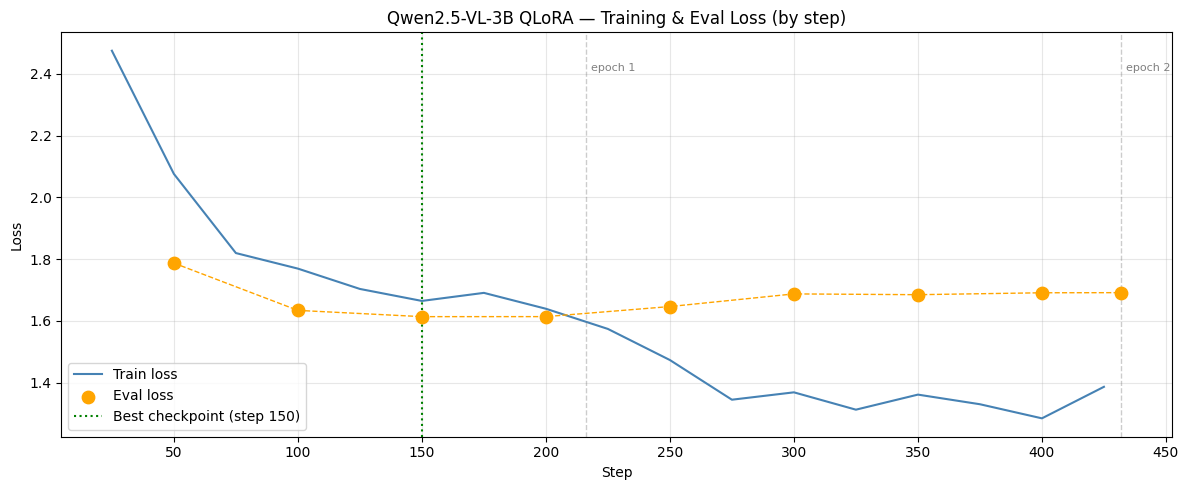

Final train loss: 1.3862
Best  eval loss:  1.6136  (step 150)
Chart saved → /kaggle/working/loss_curve.png


In [31]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
train_logs  = [(e["step"], e["loss"])      for e in log_history if "loss"      in e and "eval_loss" not in e]
eval_logs   = [(e["step"], e["eval_loss"]) for e in log_history if "eval_loss" in e]

# Tính vị trí epoch boundaries để annotate trên chart
steps_per_epoch = trainer.state.max_steps // trainer.args.num_train_epochs

fig, ax = plt.subplots(figsize=(12, 5))

if train_logs:
    steps_t, loss_t = zip(*train_logs)
    ax.plot(steps_t, loss_t, label="Train loss", color="steelblue", linewidth=1.5)

if eval_logs:
    steps_e, loss_e = zip(*eval_logs)
    ax.scatter(steps_e, loss_e, label="Eval loss", color="orange", s=80, zorder=5)
    ax.plot(steps_e, loss_e, color="orange", linestyle="--", linewidth=1)
    best_step = steps_e[loss_e.index(min(loss_e))]
    ax.axvline(best_step, color="green", linestyle=":", linewidth=1.5, label=f"Best checkpoint (step {best_step})")

# Epoch boundary lines
for ep in range(1, trainer.args.num_train_epochs + 1):
    ax.axvline(ep * steps_per_epoch, color="gray", linestyle="--", alpha=0.4, linewidth=1)
    ax.text(ep * steps_per_epoch + 2, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] else 1, f"epoch {ep}", fontsize=8, color="gray")

ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Qwen2.5-VL-3B QLoRA — Training & Eval Loss (by step)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

chart_path = OUT_ROOT / "loss_curve.png"
plt.savefig(str(chart_path), dpi=150)
plt.show()

if train_logs:
    print(f"Final train loss: {loss_t[-1]:.4f}")
if eval_logs:
    best_loss = min(loss_e)
    best_step = steps_e[loss_e.index(best_loss)]
    print(f"Best  eval loss:  {best_loss:.4f}  (step {best_step})")
print(f"Chart saved → {chart_path}")

## 6. Evaluation trên test set

### Dataset này chứng minh được gì?

| Khía cạnh | Đánh giá |
|---|---|
| **Giải thích khái niệm ML** (CS224n/CS231n/CS230) | ✅ ~4,100 mẫu, đủ bằng chứng |
| **Tutor style** (giải thích thay vì trả lời thẳng) | ✅ V2/V3 variants rèn ngữ điệu |
| **Image/frame support** | ✅ Base VLM giữ nguyên — vision tower frozen, không bị xóa |
| **Tiếng Việt** | ⚠️ 300 samples từ 5CD-AI — cải thiện nhẹ, chưa đủ cho production |
| **Visual grounding** (hiểu nội dung trong ảnh) | ⚠️ SFT data là text-only → không cải thiện, dựa vào base model |
| **Conversational / multi-turn** | ❌ Không có — chỉ single-turn Q&A |
| **Tool calling** | ❌ Không có samples tool-call |

> **Vision note:** Pipeline hiện tại gửi `image_base64` (JPEG frame) vào model. Fine-tune này không làm hỏng vision support vì tower bị freeze — model vẫn xử lý ảnh như base Qwen2.5-VL.</cell id="d8e6c778">
</invoke>

In [32]:
FastVisionModel.for_inference(model)

def generate(messages, max_new_tokens=200):
    # VLM processor's apply_chat_template(tokenize=True) breaks on text-only input
    # — split into render step (tokenize=False) then tokenize via inner tokenizer
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    model_inputs = tokenizer.tokenizer(
        text, return_tensors="pt", add_special_tokens=False
    ).to("cuda")
    with torch.no_grad():
        out = model.generate(
            **model_inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.1,
            do_sample=True,
        )
    return tokenizer.decode(
        out[0][model_inputs["input_ids"].shape[-1]:], skip_special_tokens=True
    )


test_data   = load_jsonl(OUTPUT_DIR / "test.jsonl")
test_sample = test_data[:5]

for i, sample in enumerate(test_sample):
    user_msg = next(m["content"] for m in sample["messages"] if m["role"] == "user")
    ref_msg  = next(m["content"] for m in sample["messages"] if m["role"] == "assistant")

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": user_msg},
    ]
    response = generate(messages)

    print(f"─── Sample {i+1} [{sample['variant']}] ───")
    print(f"Q:   {user_msg[:120]}")
    print(f"Ref: {ref_msg[:150]}")
    print(f"Gen: {response[:150]}")
    print()

Both `max_new_tokens` (=200) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


─── Sample 1 [v1] ───
Q:   [CS231n] What best captures why distributed training is now the default for modern deep learning?

Choices:
- Most state
Ref: The correct answer is: **Modern training commonly spans many devices, often from tens up to tens of thousands**

Modern training jobs are usually too 
Gen: The correct answer is: **Modern training commonly spans many devices, often from tens up to tens of thousands**

Distributed training is the norm toda



Both `max_new_tokens` (=200) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


─── Sample 2 [v2] ───
Q:   [CS231n] Explain the concept behind this question: What best captures why distributed training is now the default for mo
Ref: Modern training jobs are usually too large for a single accelerator, so systems distribute computation across many devices working together.

In summa
Gen: Large neural networks require enormous computation. Distributed training can spread that load across many machines, making it feasible to train much l



Both `max_new_tokens` (=200) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


─── Sample 3 [v3] ───
Q:   [CS231n] Why is 'Most state-of-the-art models are still trained on a single GPU, but evaluated on many devices' not the 
Ref: 'Most state-of-the-art models are still trained on a single GPU, but evaluated on many devices' is incorrect. Modern training jobs are usually too lar
Gen: 'Most state-of-the-art models are still trained on a single GPU, but evaluated on many devices' is incorrect. Modern deep learning often requires trai



Both `max_new_tokens` (=200) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


─── Sample 4 [v1] ───
Q:   [CS231n] Why is a 400B-scale model a useful running case study for large-scale distributed training?

Choices:
- It is t
Ref: The correct answer is: **Its paper reveals unusually detailed training-system information compared with many frontier-model papers**

The model is use
Gen: The correct answer is: **Its paper reveals unusually detailed training-system information compared with many frontier-model papers**

The 400B-scale m

─── Sample 5 [v2] ───
Q:   [CS231n] Explain the concept behind this question: Why is a 400B-scale model a useful running case study for large-scale
Ref: The model is useful as a teaching example because its paper shares concrete implementation and system details that many frontier-model reports omit.


Gen: A 400B-scale model is still relatively small compared to the largest models used today. It can be trained on many GPUs or even a single high-end machi



### 6b. Tier 0 Benchmark Eval (MMLU · GSM8K)

Zero-shot eval trên benchmark public để đo regression so với base model.

| Benchmark | N | Metric | Expected (Qwen2.5-3B base) |
|---|---|---|---|
| MMLU | 100 | Letter accuracy | ~55–60% |
| GSM8K | 50 | Exact number match | ~60–65% |

> Fine-tune này **không nên drop** các con số này xuống — nếu drop >5%, domain SFT đang ghi đè general capability.

In [33]:
import re

# ─── MMLU (zero-shot, 100 samples) ───────────────────────────────────────────
MMLU_N = 100
CHOICES = "ABCD"

try:
    mmlu_ds = hf_load("cais/mmlu", "all", split=f"test[:{MMLU_N}]", trust_remote_code=True)
    mmlu_correct = 0

    for row in mmlu_ds:
        choices_str  = "\n".join(f"{CHOICES[i]}. {c}" for i, c in enumerate(row["choices"]))
        user_content = (
            f"Question: {row['question']}\n\nChoices:\n{choices_str}\n\n"
            "Answer with the letter only (A, B, C, or D)."
        )
        resp = generate([{"role": "user", "content": user_content}], max_new_tokens=5)
        pred = resp.strip()[0].upper() if resp.strip() else "X"
        if pred == CHOICES[row["answer"]]:
            mmlu_correct += 1

    print(f"MMLU  (n={MMLU_N}): {mmlu_correct}/{MMLU_N} = {mmlu_correct/MMLU_N:.1%}")

except Exception as e:
    print(f"MMLU skipped: {e}")

# ─── GSM8K (zero-shot chain-of-thought, 50 samples) ──────────────────────────
GSM8K_N = 50

try:
    gsm8k_ds = hf_load("openai/gsm8k", "main", split=f"test[:{GSM8K_N}]")
    gsm8k_correct = 0
    gsm8k_valid   = 0

    for row in gsm8k_ds:
        gold_match = re.search(r"####\s*([\d,]+)", row["answer"])
        if not gold_match:
            continue
        gold_num = gold_match.group(1).replace(",", "")

        user_content = (
            f"Solve step by step:\n{row['question']}\n\n"
            "At the end, write your final answer as: #### <number>"
        )
        resp = generate([{"role": "user", "content": user_content}], max_new_tokens=400)
        pred_match = re.search(r"####\s*([\d,]+)", resp)
        pred_num   = pred_match.group(1).replace(",", "") if pred_match else ""

        if pred_num == gold_num:
            gsm8k_correct += 1
        gsm8k_valid += 1

    print(f"GSM8K (n={gsm8k_valid}): {gsm8k_correct}/{gsm8k_valid} = {gsm8k_correct/gsm8k_valid:.1%}")

except Exception as e:
    print(f"GSM8K skipped: {e}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'cais/mmlu' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
[datasets.load|ERROR]`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'cais/mmlu' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

all/test-00000-of-00001.parquet:   0%|          | 0.00/3.50M [00:00<?, ?B/s]

all/validation-00000-of-00001.parquet:   0%|          | 0.00/408k [00:00<?, ?B/s]

...

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Both `max_new_tokens` (=400) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=400) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=400) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=400) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

GSM8K (n=50): 30/50 = 60.0%


### 6c. Domain MCQ Accuracy (finetuned vs base)

In [34]:
predictions = []
correct     = 0
by_course   = _dd(lambda: [0, 0])

for item in bench_items:
    choices_str = "\n".join(f"{chr(65+i)}. {c}" for i, c in enumerate(item["choices"]))
    prompt = (
        f"[{item['course_id']}]\nQuestion: {item['question']}\n\n"
        f"Choices:\n{choices_str}\n\nReturn only the correct letter: A, B, C, or D."
    )
    resp = generate([{"role": "user", "content": prompt}], max_new_tokens=8)
    pred = _extract_letter(resp)
    gold = chr(65 + int(item["answer_index"]))
    ok   = pred == gold
    correct += int(ok)
    by_course[item["course_id"]][0] += int(ok)
    by_course[item["course_id"]][1] += 1
    predictions.append({
        "item_id": item.get("item_id"),
        "course_id": item.get("course_id"),
        "lecture_id": item.get("lecture_id"),
        "gold": gold, "pred": pred, "correct": ok,
    })

ft_mcq_acc = correct / max(1, len(bench_items))

print(f"Fine-tuned MCQ accuracy: {correct}/{len(bench_items)} = {ft_mcq_acc:.1%}")
for course, (c, n) in sorted(by_course.items()):
    print(f"  {course}: {c}/{n} = {c/max(1,n):.1%}")

delta = ft_mcq_acc - base_mcq_acc
print(f"\nBase:      {base_mcq_acc:.1%}")
print(f"Fine-tuned:{ft_mcq_acc:.1%}")
print(f"Delta:     {delta:+.1%}  {'✅ improved' if delta > 0 else '⚠️ degraded' if delta < -0.05 else '→ no change'}")

# Save predictions
eval_dir = OUT_ROOT / "eval"
eval_dir.mkdir(parents=True, exist_ok=True)
with open(eval_dir / "domain_mcq_predictions.jsonl", "w", encoding="utf-8") as f:
    for row in predictions:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")
with open(eval_dir / "domain_mcq_summary.json", "w", encoding="utf-8") as f:
    json.dump({
        "benchmark_items": len(bench_items),
        "base_accuracy": base_mcq_acc,
        "finetuned_accuracy": ft_mcq_acc,
        "delta": delta,
        "by_course": {c: {"correct": v[0], "total": v[1], "accuracy": v[0]/max(1,v[1])} for c, v in by_course.items()},
    }, f, ensure_ascii=False, indent=2)
print(f"Saved → {eval_dir}")

Both `max_new_tokens` (=8) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

Fine-tuned MCQ accuracy: 105/127 = 82.7%
  CS224n: 21/23 = 91.3%
  CS230: 24/42 = 57.1%
  CS231n: 60/62 = 96.8%

Base:      82.7%
Fine-tuned:82.7%
Delta:     +0.0%  → no change
Saved → /kaggle/working/eval


## 7. Save adapter + merge

Output lưu vào `/kaggle/working/` — download từ **Output** tab sau khi notebook chạy xong.

In [35]:
DO_MERGE = False  # Set True để merge LoRA vào base model (cần cho vLLM, ~6GB disk)

if DO_MERGE:
    model.save_pretrained_merged(
        str(MODEL_DIR),
        tokenizer,
        save_method="merged_16bit",
    )
    print(f"Merged model → {MODEL_DIR}")
else:
    print("Merge skipped (DO_MERGE=False) — dùng LoRA adapter để inference hoặc set DO_MERGE=True khi cần vLLM")

import subprocess
if ENV == "kaggle":
    result = subprocess.run(["du", "-sh", "/kaggle/working"], capture_output=True, text=True)
    print(f"Total output size: {result.stdout.strip()}")
    print("Download: Output tab → Download all")

Merge skipped (DO_MERGE=False) — dùng LoRA adapter để inference hoặc set DO_MERGE=True khi cần vLLM
Total output size: 685M	/kaggle/working
Download: Output tab → Download all


In [36]:
model.save_pretrained("/kaggle/working/lora_adapter")
tokenizer.save_pretrained("/kaggle/working/lora_adapter")

Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/lora_adapter/tokenizer_config.json.


['/kaggle/working/lora_adapter/processor_config.json']

In [37]:
import os

for root, dirs, files in os.walk("/kaggle/working/lora_adapter"):
    for f in files:
        print(os.path.join(root, f))

/kaggle/working/lora_adapter/README.md
/kaggle/working/lora_adapter/chat_template.jinja
/kaggle/working/lora_adapter/tokenizer.json
/kaggle/working/lora_adapter/adapter_config.json
/kaggle/working/lora_adapter/processor_config.json
/kaggle/working/lora_adapter/tokenizer_config.json
/kaggle/working/lora_adapter/adapter_model.safetensors
